#Imports e leitura

In [9]:
import pandas as pd

##Execução via Colab (padrão)

In [30]:
url = "https://raw.githubusercontent.com/SeanTorres12/case_solfacil/refs/heads/main/data/vgsales.csv"
df = pd.read_csv(url)

##Execução local

In [ ]:
#df = pd.read_csv("data/vgsales.csv")

##Visualizar arquivo

In [12]:
df.head()

,Nome,Plataforma,Ano,Gênero,Publisher,Vendas Globais (milhões)
0,Super Mario Galaxy,Wii,2007,Platform,Nintendo,11.35
1,Call of Duty: Modern Warfare 2,X360,2009,Shooter,Activision,13.52
2,Wii Sports Resort,Wii,2009,Sports,Nintendo,33.09
3,Grand Theft Auto V,PS4,2014,Action,Take-Two Interactive,20.32
4,Minecraft,PC,2011,Misc,Mojang,25.50


##Texto

In [27]:
def conclusao():
    texto = """
- Shooter é o gênero que mais vendeu globalmente, com uma vantagem de mais de
  25 milhões de unidades sobre o segundo colocado — a maior diferença entre todos
  os itens do top 5, que entre si têm diferenças bem menores.

- O número de lançamentos caiu em 2019 e voltou a subir em 2020. Em um cenário
  real, esse padrão coincidiria com o período de lockdown, que provavelmente também
  teria elevado o volume de vendas.

- O PC é a plataforma dominante, com mais do que o dobro de jogos lançados em
  relação ao segundo colocado (PS4). Isso provavelmente reflete fatores do mundo
  real: jogos mais baratos, catálogo maior (incluindo "exclusivos" de outras
  plataformas) e o fato de o PC servir a múltiplos propósitos além de jogos —
  como trabalho e estudo.
"""
    print(texto)


#Visão geral


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Nome                      72 non-null     object 
 1   Plataforma                72 non-null     object 
 2   Ano                       72 non-null     int64  
 3   Gênero                    72 non-null     object 
 4   Publisher                 72 non-null     object 
 5   Vendas Globais (milhões)  72 non-null     float64
dtypes: float64(1), int64(1), object(4)
memory usage: 3.5+ KB


#Tarefa 1: Verificar dados faltantes

In [14]:
print(df.isna().sum())


Nome                        0
Plataforma                  0
Ano                         0
Gênero                      0
Publisher                   0
Vendas Globais (milhões)    0
dtype: int64


In [ ]:
#Não há dados faltantes, mas a remoção seria com:
df = df.dropna(subset=["Ano"])

##Análise Descritiva

###Qual é o gênero de jogo que mais vendeu globalmente?


In [15]:
vendas_genero = df.groupby("Gênero")["Vendas Globais (milhões)"].sum().sort_values(ascending=False)
vendas_genero

,Vendas Globais (milhões)
Gênero,
Shooter,209.16
Battle Royale,175.00
Role-Playing,150.80
Action-Adventure,134.03
Simulation,100.82
MOBA,100.00
Platform,94.68
Action-RPG,87.50
Sports,84.03


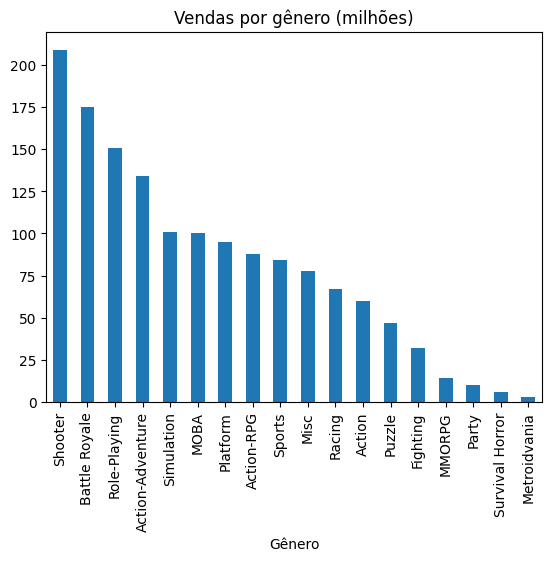

In [16]:
vendas_grafico = vendas_genero.plot.bar(x="Gênero", y="Vendas Globais (milhões)", rot=90, title="Vendas por gênero (milhões)")

###Qual plataforma (console) teve o maior número de jogos lançados?

In [17]:
jogos_por_plataforma = df["Plataforma"].value_counts()
jogos_por_plataforma

,count
Plataforma,
PC,21
PS4,9
X360,7
NS,6
Wii,4
PS2,4
PS,3
N64,3
SNES,3


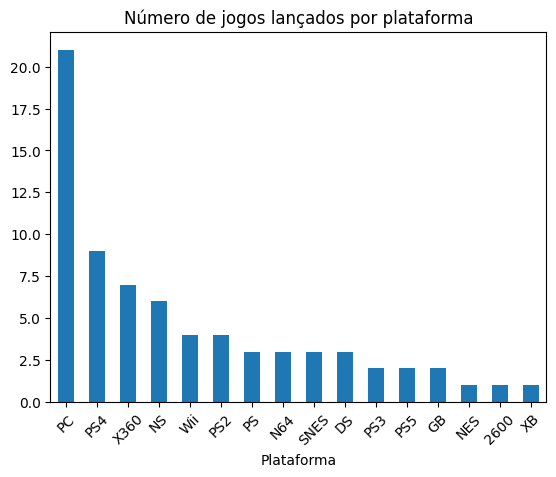

In [18]:
plataforma_grafico = jogos_por_plataforma.plot.bar(x="Plataforma", y="Count", rot=45, title="Número de jogos lançados por plataforma")

###Crie uma nova coluna chamada Decada que classifique cada jogo como sendo dos "Anos 90" (1990-1999), "Anos 2000" (2000-2009) ou "Anos 2010" (2010-2016)

In [19]:
bins = [1990, 2000, 2010, 2017]
labels = ['Anos 90', 'Anos 2000', 'Anos 2010']

df['Decada'] = pd.cut(df['Ano'], bins=bins, labels=labels, right=False)

df.head()

,Nome,Plataforma,Ano,Gênero,Publisher,Vendas Globais (milhões),Decada
0,Super Mario Galaxy,Wii,2007,Platform,Nintendo,11.35,Anos 2000
1,Call of Duty: Modern Warfare 2,X360,2009,Shooter,Activision,13.52,Anos 2000
2,Wii Sports Resort,Wii,2009,Sports,Nintendo,33.09,Anos 2000
3,Grand Theft Auto V,PS4,2014,Action,Take-Two Interactive,20.32,Anos 2010
4,Minecraft,PC,2011,Misc,Mojang,25.50,Anos 2010


In [20]:
df["Decada"].value_counts(dropna=False)

,count
Decada,
NaN,25
Anos 2000,20
Anos 2010,17
Anos 90,10


###Top 5

,Vendas Globais (milhões)
Gênero,
Shooter,209.16
Battle Royale,175.00
Role-Playing,150.80
Action-Adventure,134.03
Simulation,100.82


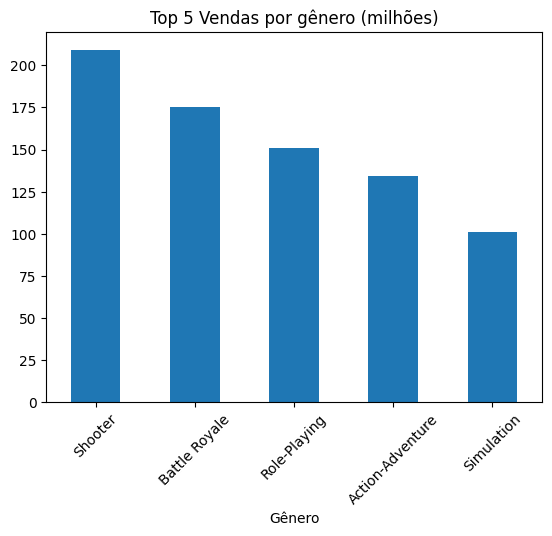

In [21]:
top_5_generos = vendas_genero.nlargest(5)
display(top_5_generos)
vendas_grafico = top_5_generos.plot.bar(x="Gênero", y="Vendas Globais (milhões)", rot=45, title="Top 5 Vendas por gênero (milhões)")

###Vendas Por ano

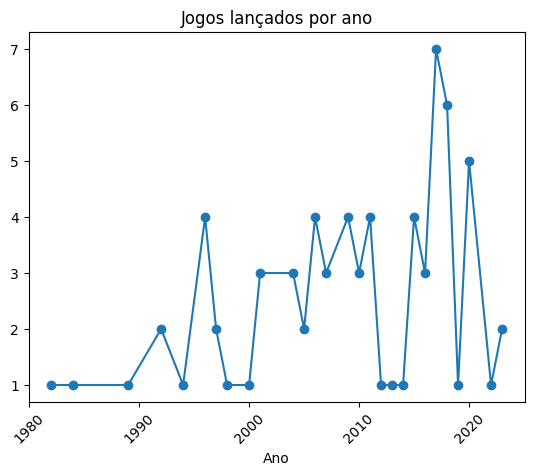

In [26]:
jogos_por_ano = df.groupby("Ano").size()
grafico_lancamentos = jogos_por_ano.plot.line(rot=45, title="Jogos lançados por ano", marker="o")

In [28]:

conclusao()


- Shooter é o gênero que mais vendeu globalmente, com uma vantagem de mais de
  25 milhões de unidades sobre o segundo colocado — a maior diferença entre todos
  os itens do top 5, que entre si têm diferenças bem menores.

- O número de lançamentos caiu em 2019 e voltou a subir em 2020. Em um cenário
  real, esse padrão coincidiria com o período de lockdown, que provavelmente também
  teria elevado o volume de vendas.

- O PC é a plataforma dominante, com mais do que o dobro de jogos lançados em
  relação ao segundo colocado (PS4). Isso provavelmente reflete fatores do mundo
  real: jogos mais baratos, catálogo maior (incluindo "exclusivos" de outras
  plataformas) e o fato de o PC servir a múltiplos propósitos além de jogos —
  como trabalho e estudo.

